## LOAD DATA & FEATURE ENGINEERING

## KALKULASI NORMAL EQUATION

Beta = (X^T * X)^-1 * X^T * Y

In [8]:
#Transpose Matrix X
X_T=X.T

#Dot Product X^T * X
X_T_X=np.dot(X_T, X)

#Inverse
X_T_X_inv = np.linalg.inv(X_T_X)

#Dot Product X_T * Y
X_T_Y = np.dot(X_T, Y)

#Hasil Akhir Koefiesien
beta = np.dot(X_T_X_inv, X_T_Y)

In [9]:
# Hitung prediksi Y (Y_hat = X * Beta)
Y_pred = np.dot(X, beta)

# Sum of Squares Residual (Error)
SS_res = np.sum((Y - Y_pred) ** 2)

# Sum of Squares Total (Varian total dari Y)
SS_tot = np.sum((Y - np.mean(Y)) ** 2)

# Nilai R-Squared
R_squared = 1 - (SS_res / SS_tot)

#TAMPILKAN HASIL
print(f"Intercept (Beta_0)         : {beta[0]:.4f}")
print(f"Koefisien panjang_input    : {beta[1]:.4f}")
print(f"Koefisien is_jawa          : {beta[2]:.4f}")
print(f"Koefisien is_sunda         : {beta[3]:.4f}")
print(f"Koefisien is_qwen2         : {beta[4]:.4f}")
print(f"Koefisien is_gemma2        : {beta[5]:.4f}")
print("-" * 46)
print(f"R-Squared                  : {R_squared:.4f}")

Intercept (Beta_0)         : 54.0979
Koefisien panjang_input    : 0.2091
Koefisien is_jawa          : -0.0658
Koefisien is_sunda         : -3.7959
Koefisien is_qwen2         : -4.3973
Koefisien is_gemma2        : -12.7516
----------------------------------------------
R-Squared                  : 0.2265


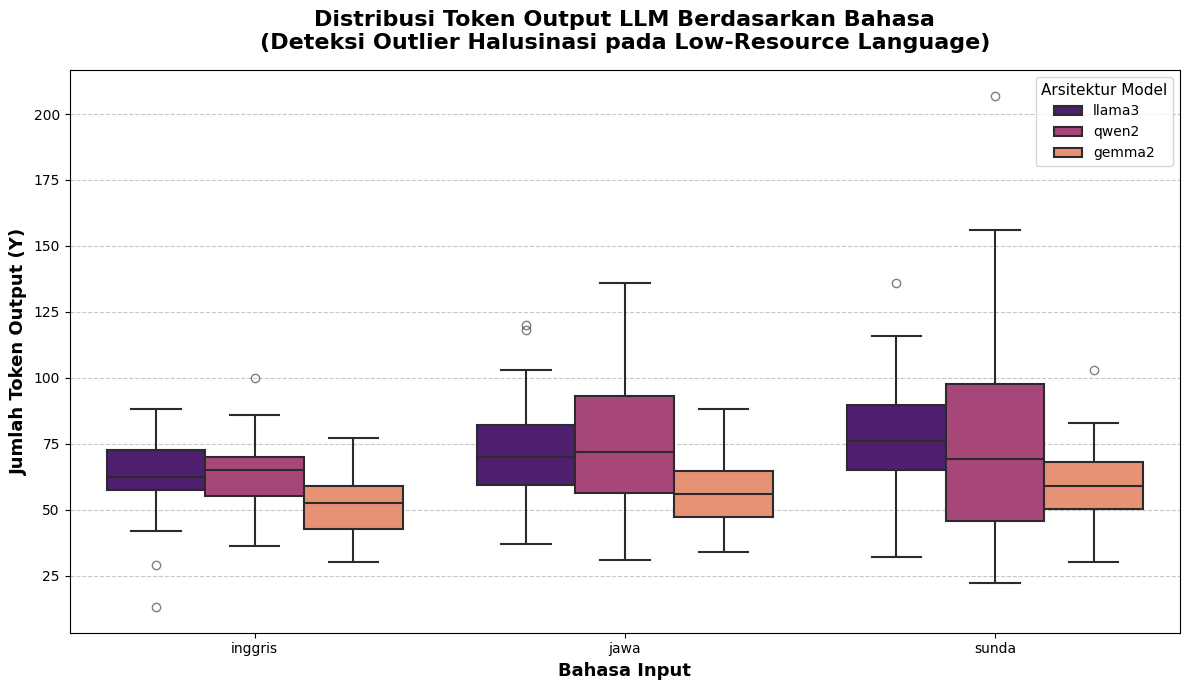

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 7))

sns.boxplot(
    data=df, 
    x='bahasa', 
    y='token_output', 
    hue='model', 
    palette='magma',
    linewidth=1.5,
    flierprops=dict(marker='o', color='red', markersize=6, alpha=0.6)
)

plt.title('Distribusi Token Output LLM Berdasarkan Bahasa\n(Deteksi Outlier Halusinasi pada Low-Resource Language)', 
          fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Bahasa Input', fontsize=13, fontweight='bold')
plt.ylabel('Jumlah Token Output (Y)', fontsize=13, fontweight='bold')

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(title='Arsitektur Model', title_fontsize='11', fontsize='10', loc='upper right')

plt.tight_layout()
plt.show()

<>:21: SyntaxWarning: "\h" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\h"? A raw string is also an option.
<>:38: SyntaxWarning: "\h" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\h"? A raw string is also an option.
<>:21: SyntaxWarning: "\h" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\h"? A raw string is also an option.
<>:38: SyntaxWarning: "\h" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\h"? A raw string is also an option.
/var/folders/2k/9v42dhzd2rdg1nkfsqt49skw0000gn/T/ipykernel_48265/988251064.py:21: SyntaxWarning: "\h" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\h"? A raw string is also an option.
  axes[0].set_xlabel('Predicted Token Output ($\hat{Y}$)', fontsize=12)
/var/folders/2k/9v42dhzd2rdg1nkfsqt49skw0000gn/T/ipykernel_48265/988251064.py:38: S

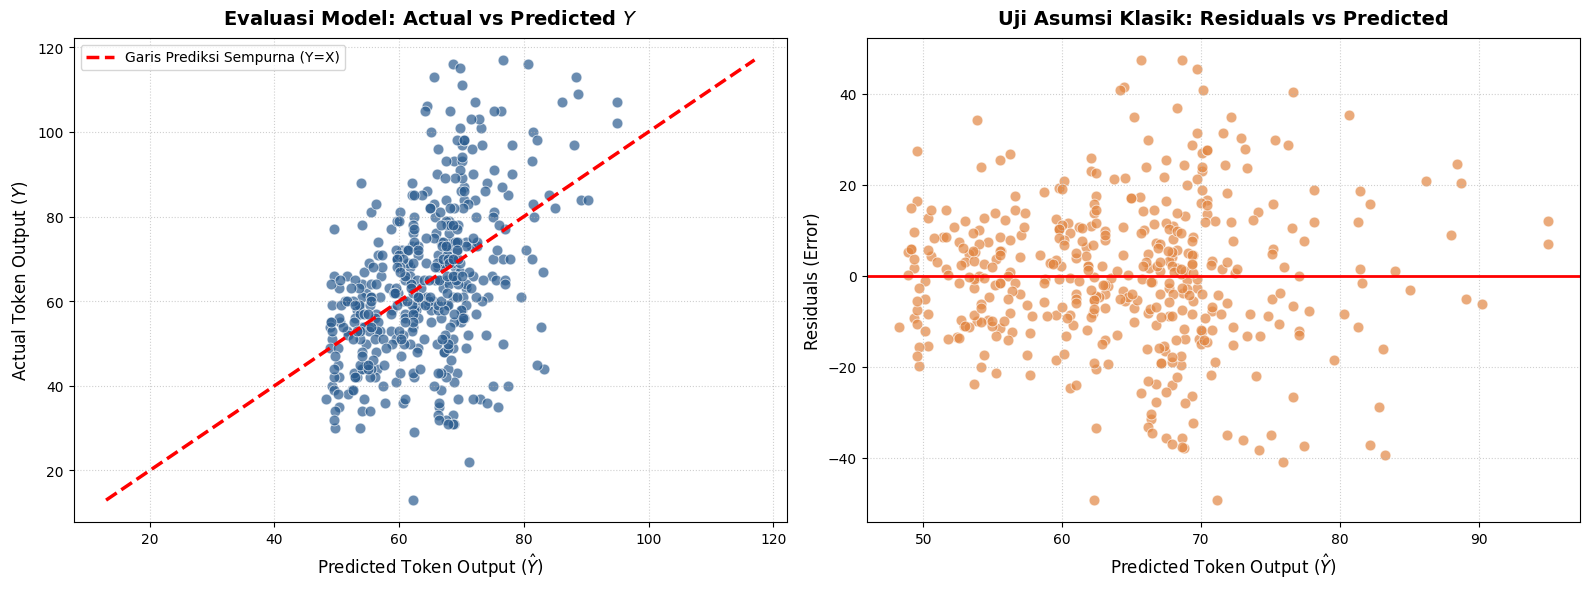

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.scatterplot(x=Y_pred, y=Y, ax=axes[0], color='#2b5c8f', alpha=0.7, edgecolor='w', s=60)


min_val = min(min(Y_pred), min(Y))
max_val = max(max(Y_pred), max(Y))
axes[0].plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', linewidth=2.5, label='Garis Prediksi Sempurna (Y=X)')

axes[0].set_title('Evaluasi Model: Actual vs Predicted $Y$', fontsize=14, fontweight='bold', pad=10)
axes[0].set_xlabel('Predicted Token Output ($\hat{Y}$)', fontsize=12)
axes[0].set_ylabel('Actual Token Output ($Y$)', fontsize=12)
axes[0].legend()
axes[0].grid(True, linestyle=':', alpha=0.6)

residuals = Y - Y_pred 

sns.scatterplot(x=Y_pred, y=residuals, ax=axes[1], color='#e28743', alpha=0.7, edgecolor='w', s=60)

axes[1].axhline(y=0, color='red', linestyle='-', linewidth=2)

axes[1].set_title('Uji Asumsi Klasik: Residuals vs Predicted', fontsize=14, fontweight='bold', pad=10)
axes[1].set_xlabel('Predicted Token Output ($\hat{Y}$)', fontsize=12)
axes[1].set_ylabel('Residuals (Error)', fontsize=12)
axes[1].grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()